In [1]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = C:\Users\hodor\Documents\lab-Shishkin\projects\Agency EBCI\Agency_BCI


In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

In [70]:
from src.utils.parse_h5df import load_h5df, ttl2binary, reverse_trigger
from src.utils.parse_resonance_files import parse_events
from src.utils.montage_processing import *
from src.utils.events import slice_epochs
from src.analysis.preprocessing import bandpass_filter

In [18]:
Fs=1000

In [ ]:
def get_topo_positions(fl_montage):
    df = pd.read_csv(fl_montage, sep='\t')
    th = np.pi / 180 * np.array(df.theta.values)
    df['y'] = np.round(np.array(df.radius.values) * np.cos(th), 2)
    df['x'] = np.round(np.array(df.radius.values) * np.sin(th), 2)
    return df[['x', 'y']].values
xy = get_topo_positions(f"../resources/mks64_standard.ced")[good_channels_idx]

In [308]:
path_filename= r"..\data\test\03_16 Artem\05_calib.hdf"
data, _ = load_h5df(path_filename)
trigger = data[:, -1]
trigger = ttl2binary(data[:, -1], bit_index=0)
trigger = reverse_trigger(trigger)

In [309]:
bad_channels = ["FT9", "TP9", "T7", "AF7", "AF8", "FT10", "TP10", "T8"]
labels = get_channel_names(r"../resources/mks64_standard.ced")
good_channels_idx = np.array([find_ch_idx(ch, r"../resources/mks64_standard.ced") for ch in labels if not(ch in bad_channels)])
good_channels_idx

array([ 2,  3,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20, 21, 22, 23, 24, 25, 26, 28, 29, 32, 33, 35, 36, 37, 38, 39, 40,
       41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57,
       58, 59, 60, 62, 63])

In [310]:
eeg = data[:, good_channels_idx] * 1E6
eeg, _ = bandpass_filter(eeg, fs=Fs, low=1, high=40)

In [311]:
start_shift = 500
idxs_rest, idxs_right, idxs_left = parse_events(trigger, window_size=200, start_shift=start_shift, end_shift=0)

In [312]:
epochs_1, epochs_2 = slice_epochs(eeg, idxs_right)[:, start_shift:, :], slice_epochs(eeg, idxs_left)[:, start_shift:, :]

In [313]:
fl_montage = r"../resources/mks64_standard.ced"
idx_C4 = find_ch_idx("C4", fl_montage)
idx_C3 = find_ch_idx("C3", fl_montage)

In [314]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch


def plot_psd_channel(epochs, sfreq, ch_idx, label=None, fmin=1, fmax=40):
    """
    epochs : [n_trials, samples, channels]
    sfreq  : частота дискретизации
    ch_idx : индекс канала
    label  : подпись (например 'left' / 'right')
    """

    psds = []

    for ep in epochs:
        signal = ep[:, ch_idx]

        freqs, psd = welch(
            signal,
            fs=sfreq,
            nperseg=sfreq * 2,   # окно ~2 сек
            noverlap=sfreq       # 50% overlap
        )

        psds.append(psd)

    psds = np.array(psds)
    mean_psd = psds.mean(axis=0)
    std_psd = psds.std(axis=0)

    # ограничение частот
    mask = (freqs >= fmin) & (freqs <= fmax)

    freqs = freqs[mask]
    mean_psd = mean_psd[mask]
    std_psd = std_psd[mask]

    # в dB
    mean_psd_db = 10 * np.log10(mean_psd)
    std_psd_db = 10 * np.log10(std_psd + 1e-12)

    plt.plot(freqs, mean_psd_db, label=label)
    plt.fill_between(
        freqs,
        mean_psd_db - std_psd_db,
        mean_psd_db + std_psd_db,
        alpha=0.2
    )

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Power (dB)")
    plt.title(f"PSD (channel {ch_idx})")
    plt.grid(True)

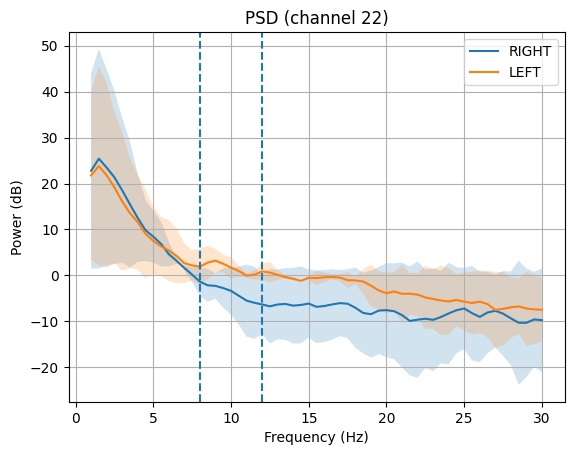

In [315]:
plot_psd_channel(epochs_1, sfreq=Fs, ch_idx=idx_C3, label="RIGHT", fmin=1, fmax=30)
plot_psd_channel(epochs_2, sfreq=Fs, ch_idx=idx_C4, label="LEFT", fmin=1, fmax=30)
plt.axvline(8, linestyle="--")
plt.axvline(12, linestyle="--")
plt.legend()
plt.show()

In [316]:
def plot_log_ratio_psd(epochs_left, epochs_right, sfreq, ch_idx, fmin=1, fmax=40):
    """
    log-ratio PSD: log(P_left / P_right)
    """

    def compute_mean_psd(epochs):
        psds = []
        for ep in epochs:
            freqs, psd = welch(
                ep[:, ch_idx],
                fs=sfreq,
                nperseg=sfreq * 2,
                noverlap=sfreq
            )
            psds.append(psd)
        return freqs, np.mean(psds, axis=0)

    freqs, psd_left = compute_mean_psd(epochs_left)
    _, psd_right = compute_mean_psd(epochs_right)

    # защита от нулей
    eps = 1e-12
    log_ratio = np.log(psd_left + eps) - np.log(psd_right + eps)

    # ограничение диапазона
    mask = (freqs >= fmin) & (freqs <= fmax)

    plt.figure(figsize=(8, 5))
    plt.plot(freqs[mask], log_ratio[mask])

    plt.axhline(0, linestyle="--")
    plt.axvline(8, linestyle="--", alpha=0.5)
    plt.axvline(12, linestyle="--", alpha=0.5)
    plt.xticks(np.arange(fmin, fmax, 2))

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("log(P_left / P_right)")
    plt.title(f"Log-Ratio PSD (channel {ch_idx})")
    plt.grid(True)
    plt.show()

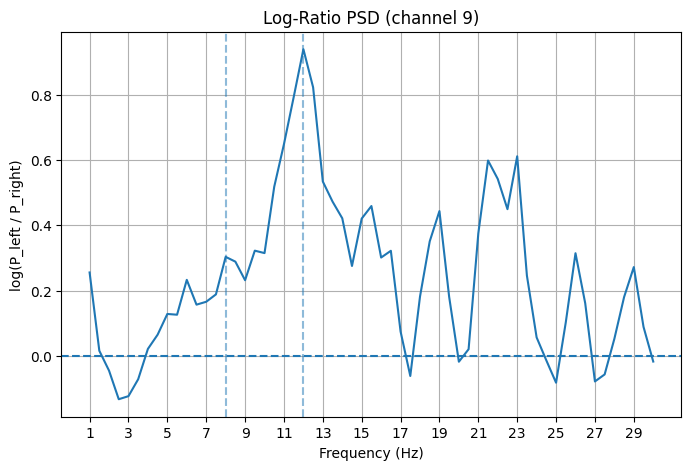

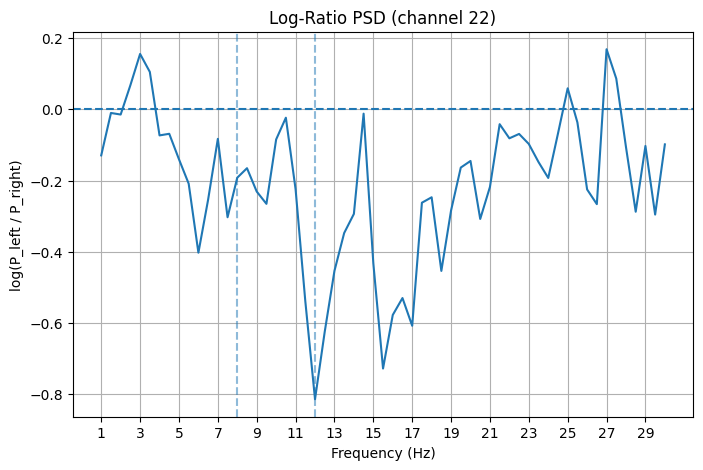

In [317]:
plot_log_ratio_psd(epochs_2, epochs_1, sfreq=Fs, ch_idx=idx_C3, fmin=1, fmax=30)
plot_log_ratio_psd(epochs_1, epochs_2, sfreq=Fs, ch_idx=idx_C4, fmin=1, fmax=30)

In [328]:
from scipy.signal import  hilbert
from scipy.signal import butter, filtfilt

def bandpass(data, sfreq, fmin, fmax, order=4):
    nyq = sfreq / 2
    b, a = butter(order, [fmin / nyq, fmax / nyq], btype="band")
    return filtfilt(b, a, data, axis=0)

def plot_erd(epochs, sfreq, ch_idx, tmin, baseline=(-1.0, 0.0), band=(8, 14), label=None):
    """
    ERD/ERS (% изменения мощности относительно baseline)

    epochs: [n_trials, samples, channels]
    tmin: время начала эпохи (в секундах)
    """

    n_trials, n_samples, _ = epochs.shape
    times = np.arange(n_samples) / sfreq + tmin

    # фильтрация
    filtered = np.array([bandpass(ep[:, ch_idx], sfreq, band[0], band[1]) for ep in epochs])
    
    # мощность (amplitude^2)
    analytic = hilbert(filtered, axis=1)
    power = np.abs(analytic)**2  # мощность
    
    # baseline
    baseline_mask = (times >= baseline[0]) & (times <= baseline[1])
    if not baseline_mask.any():
        raise ValueError("Baseline вне диапазона эпохи!")
    baseline_power = power[:, baseline_mask].mean(axis=1, keepdims=True)
    print("Baseline mean:", baseline_power.mean())

    # ERD по trial
    erd = (power - baseline_power) / baseline_power * 100  # в процентах

    # усреднение по trial
    mean_erd = erd.mean(axis=0)
    std_erd = erd.std(axis=0)

    plt.figure(figsize=(8, 5))

    plt.plot(times, mean_erd, label=label)
    # plt.fill_between(
    #     times,
    #     mean_erd - std_erd,
    #     mean_erd + std_erd,
    #     alpha=0.2
    # )

    plt.axhline(0, linestyle="--")
    plt.axvline(0, linestyle="--")  # cue

    plt.xlabel("Time (s)")
    plt.ylabel("ERD (%)")
    plt.title(f"ERD ({band[0]}–{band[1]} Hz), channel {ch_idx}")
    plt.grid(True)

    if label:
        plt.legend()

    plt.show()

Baseline mean: 4.818617455956659


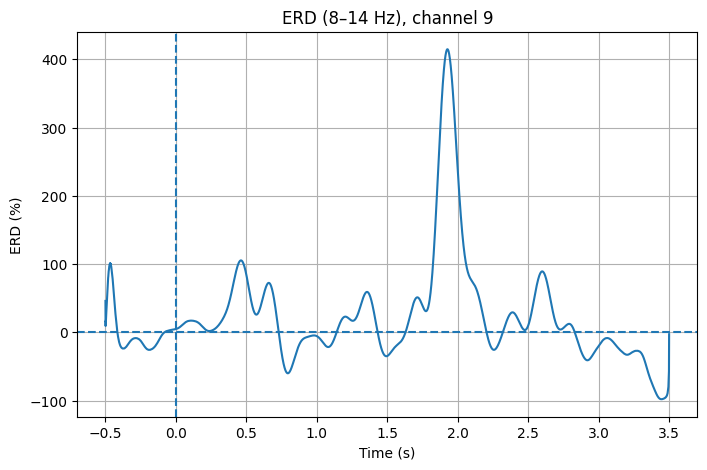

Baseline mean: 12.392061605637856


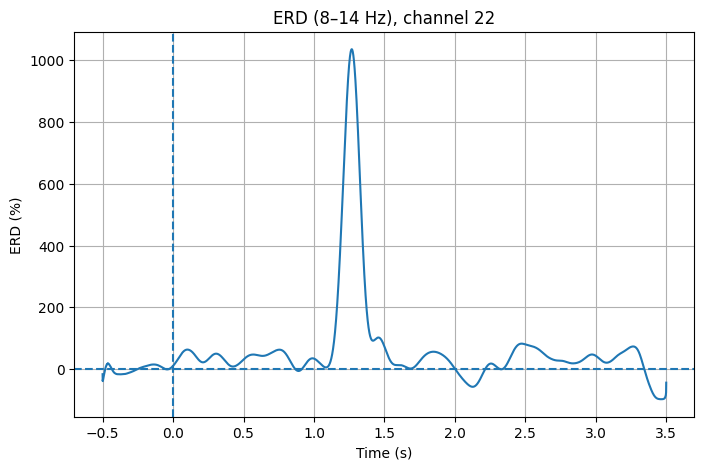

In [329]:
plot_erd(epochs_1, sfreq=Fs, ch_idx=idx_C3, tmin=-start_shift/1000, baseline=(-start_shift/1000, 0.0), label=None)
plot_erd(epochs_2, sfreq=Fs, ch_idx=idx_C4, tmin=-start_shift/1000, baseline=(-start_shift/1000, 0.0), label=None)

In [337]:
n = 250 // (1000 // Fs)
epochs_1, epochs_2 = slice_epochs(eeg, idxs_right)[:, n+start_shift:-n:, :], slice_epochs(eeg, idxs_left)[:, n+start_shift:-n:, :]
band = (8, 12)
epochs_1_f = np.array([bandpass_filter(ep, fs=Fs, low=band[0], high=band[1])[0] for ep in epochs_1])
epochs_2_f = np.array([bandpass_filter(ep, fs=Fs, low=band[0], high=band[1])[0] for ep in epochs_2])

In [344]:
from src.analysis.CSP import compute_csp

projInverse, projForward, evals = compute_csp(epochs_1, epochs_2, robust=False)

zero-size array to reduction operation maximum which has no identity


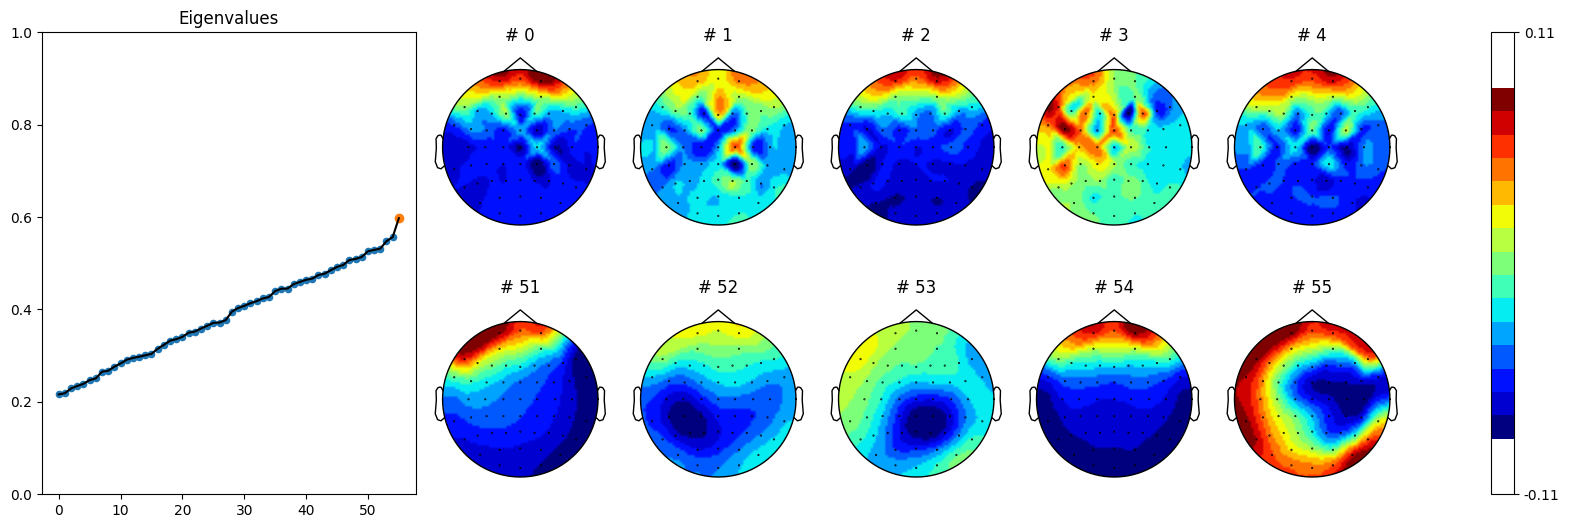

In [345]:
from src.visualization.plot_csp_components import plot_10_csp_components

fig = plot_10_csp_components(abs(evals), projForward, xy)